# Quantization

**Motivation**:  

LLMs are very large and have millions and billions of parameters . So training them or just running them (inference) is a huge challenge for consumer users and also for some companies . To solve this we reduce the *storage* used by every weight of the model. **But how ?**

# <u>Introduction and context :</u>  

Usually a weight is a float that is stored in 32 bits , that what we call a : **fp32** .  

In general every *float* representation is divided in 3 differents parts that contains different number of bit depending on the float format :  

**Float32**:  

1) *The sign (1 bit):* 1 if the float is negative 0 else
2) *The exponent (8 bits):* a base two to the power of the integer represented by the bits 
3) *The mantissa (23 bits):* the sum of powers of negative two 

Here is an example to understand how it works :  
Let's consider  the float : **5.75**.  

It's positive --> Sign bit = 0 

$$ 5.75 = 5 + 0.75 = 5 + 0.25 + 0.5 $$

But :
$$ 5 = 101_{2}$$
$$ 0.25 + 0.5 = 2⁻¹ + 2⁻²  = 11_{2} $$

So :  
$$ 5.75_{2} = 101.11_{2} = 1.0111_{2} * 2² $$

So the *exponent* is:  
$$ exponent = 127 + 2 = 129 =  10000001_{2} $$

And the mantissa is : 
$$ 01110000000000000000000_{2} $$

Finally in **FP32** :
$$ 5.75 _{10} = 0\,10000001\,01110000000000000000000_{2} $$

Here is a quick recap in one image of what I explained above  (https://huggingface.co/blog/4bit-transformers-bitsandbytes):  

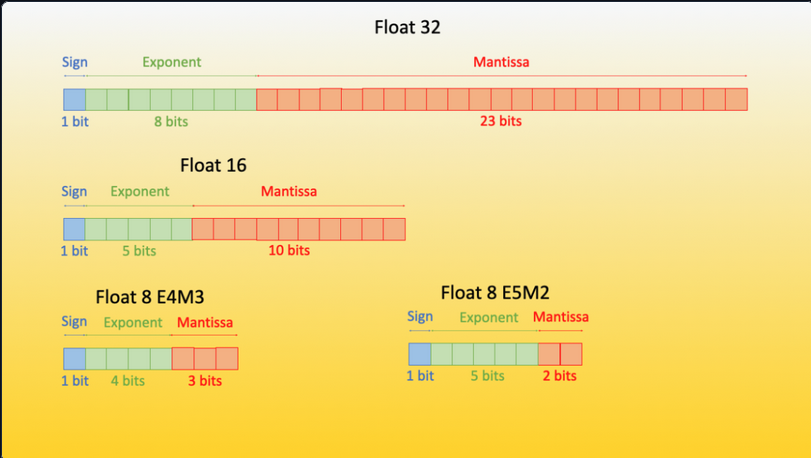

# The goal is simply to use less bits to store weights ! 

The main idea of quantization is the following one:  

- Apply a function to our **W** matrix that will transform every 32fp to a 4fp.



# 1) INT8 quantization method :

Here is how this method works:

1) Find the max of the weights of the matrix *W* :    $w_{max}$
2) Calculate the scale coefficient:  $scale = w_{max}/127$
3) Map every coefficient to 8bits integer between [-127 , 127]:  
$$ w_{int8} = round(w_{fp32}/scale)$$

In [ ]:
#Here is a quick implementation with lists
def int8_quantization(l):
    w_max = max(l)
    scale = w_max / 127
    q = []
    for x in l:
        q.append(round(x / scale))
    return q, scale

def dequantize_int8(l, scale):
    dq = []
    for x in l:
        dq.append(x * scale)
    return dq

def mmse(l1, l2):
    assert len(l1) == len(l2), "Lists must have the same length"
    err = 0.0
    for a, b in zip(l1, l2):
        err += (a - b) ** 2
    return err / len(l1)

def sep():
    print("-"*2129)
weight_fp32 = [1.1, 1.9, 3.2 , 3.1, 0.01, 0.0141]
print(f"Initial weight : {weight_fp32}")
sep()
quantized_weight,scale = int8_quantization(weight_fp32)
print(f"Quantized with int8 method : {quantized_weight}")
sep()
dequantize_list = dequantize_int8(quantized_weight,scale)
print(f"Dequantized weights : {dequantize_list}")
sep()
mmse = mmse(dequantize_list,weight_fp32)
print(f"The MMSE between the inital and dequantized list is: {mmse} ")
   

We can see that we have a very small MMSE, but the **real problem** is that in real LLMs the weights are **not uniformly distributed**.  
They are extremely **concentrated around zero**, with only a few large values far away from 0.

So even if the numeric error looks small in toy examples, in practice INT8 ends up **crushing a lot of small but meaningful weights** —  
and those tiny values are exactly where the model stores subtle information (context, tone, long-range token dependencies, etc.).

> Result → you get a model that feels dumber: less fluent, less coherent, more robotic.

In short: **INT8 assumes a uniform range**, but neural weights are **normal/Gaussian-like**, so INT8 wastes precision where it matters most.

---

## 2) NF8 method :

To keep accuracy without exploding memory, we need a quantization format that **matches the real statistical distribution of neural weights**, instead of forcing them into a uniform grid like INT8.

That's where **NF8 (NormalFloat 8)** comes in.

NF8:

- doesn't assume uniform distribution
- uses levels shaped like a **normal distribution**
- preserves small weights near zero (where most information lives)
- avoids killing subtle gradients and attention weights

> **NF8 gives you the speed/memory benefits of 8-bit,  
but behaves like a smart precision-preserving format.**

---

# How NF8 works in practice ?

1) Take the weight matrix, flatten it and split it into equal-sized blocks  
   (e.g., blocks of 64 / 128 values — local quantization instead of global)

2) For each block, find the absolute maximum weight, and scale all values in the block by that max  
   → This normalizes the block into the range [-1, 1]

3) Instead of mapping to a uniform INT8 grid, map each scaled value to the **closest NF8 code**  
   (NF8 uses a predefined set of 256 floating-point values shaped like a **normal distribution**, giving more precision near 0)

4) Store the 8-bit code + the block scale factor  
   (you only need 1 scale per block, not per value)

5) During inference, dequantize by:  

$$
   w_{deq} = NF8\_lookup(code) \times scale
   $$

This way, NF8 keeps way more resolution for small values (where most LLM weights live) while still being compact and fast like INT8.


In [ ]:
#Simple example for NF_4 (afterward we pack 2 uint4 in on uint8 register)
import torch 

NF4_quant_levels = torch.tensor([-1.0, -0.6961928009986877, -0.5250730514526367, -0.39491748809814453, -0.28444138169288635, -0.18477343022823334, -0.09105003625154495, 0.0, 0.07958029955625534, 0.16093020141124725, 0.24611230194568634, 0.33791524171829224, 0.44070982933044434, 0.5626170039176941, 0.7229568362236023, 1.0])
nf4_quant_4bit = torch.tensor([0b0000, 0b0001, 0b0010, 0b0011, 0b0100, 0b0101, 0b0110, 0b0111, 0b1000, 0b1001, 0b1010, 0b1011, 0b1100, 0b1101, 0b1110, 0b1111])
def nf4_quantization(W : torch.Tensor) :
    W_flatten = W.flatten()
    w_max = W_flatten.abs().max()
    
    #Let's normalize the W
    W_norm = W_flatten/ w_max
    
    #Now we can map every value to the index (in binary here) to it's closest nf4 approximation
    W_quantized = torch.zeros(W_norm.shape , dtype=torch.int) 
    for i,val in enumerate(W_norm):
        arg_min = torch.argmin(torch.abs(NF4_quant_levels - val))
        W_quantized[i] = nf4_quant_4bit[arg_min]
    return W_quantized , w_max

def nf4_dequantization(W, w_max):
    idx = torch.tensor([int(val) for val in W], dtype=torch.long)
    return NF4_quant_levels[idx] * w_max

def mmse_torch(t1, t2):
    assert t1.shape == t2.shape, "Shapes must match"
    mmse = (t1 - t2) ** 2
    val = torch.sum(mmse) / t1.numel()
    return mmse,val

W = torch.randn(6,5,dtype=torch.float32)*0.1 # We shrink it by decreasing the variance
W_q,w_max = nf4_quantization(W)
W_dq = nf4_dequantization(W_q,w_max).view(W.shape)
mmse_torch , val =mmse_torch(W,W_dq)
print(f"Here is the initial tensor : {W}")
sep()
print(f"Here is the quantized tensor : {W_q}")
sep()
print(f"Here is the dequantized version : {W_dq}")
sep()
print(f"The MMSE tensor is :{mmse_torch} and the total mmse is : {val}")
#MMSE tensor means the  Square error between the dequantize and initial tensors.

In reality registers can only contains 8 byte integers (uint8) so let's write the final function that will  store the two uint4 in a uint8.

In [ ]:
def quantize(W : torch.tensor):
    W_quantized_4bits, _ = nf4_quantization(W)
    l = []
    #The goal here is to put a pair of 4uint in one 8uint register , so we have to deal with an odd len situation
    if len(W_quantized_4bits) % 2 == 1:
        W_quantized_4bits = torch.cat([W_quantized_4bits,torch.tensor([0], dtype=torch.int)])
    for i in range(0,len(W_quantized_4bits),2):
        val = (W_quantized_4bits[i] << 4 ) & 0xFF
        val = val | W_quantized_4bits[i+1]
        l.append(val)
    W_packed_8_bits = torch.tensor(l,dtype=torch.uint8)
    return W_packed_8_bits

W_pack = quantize(torch.randn(6,5,dtype=torch.float32)*0.1)
print(W_pack)
print(W_pack.numel() * W_pack[1].element_size())

# HuggingFace implementation with `BitsAndBytesConfig`

Now that we have all the theory let's see how hugginface implements this quantization in the *transformer framework*.
Here is the meaning of some parameters that I thinks are important:  
- `load_in_4bit`:  **boolean**  , load the model in the gpu by storing the weight in 4 bit (instead of fp32 )
- `bnb_4bit_quant_type` : '**fp4'|'nf4'**, type of quantization wanted 
- `bnb_4bit_compute_dtype`: '**bfloat16' | 'float16'** , it's the type used for calculus (by dequantizing the weights)
- `bnb_4bit_use_double_quant`: **bolean** , two level quantization to minimize storage errors on the 4 bits

In [ ]:
from transformers import BitsAndBytesConfig, AutoModelForCausalLM, AutoTokenizer , pipeline
from peft import prepare_model_for_kbit_training
import torch

nf4_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant= True
)

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config= nf4_config,offload_folder="offload", device_map = "auto")

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast = True)


# Important : 

**Normalization layers**:  
The contains reduction operations like sum or average what can create *NaN* because of the bad precision of *int4/8* so for that we upcast these layers to *fp32*

In [33]:
NF4_model = prepare_model_for_kbit_training(model)
